# Clinical Note Specialty Classification Using Natural Language Processing (NLP)

## Healthcare NLP Project

This project builds a machine learning model to classify clinical note text into medical specialties using Natural Language Processing (NLP). The goal is to simulate a real-world healthcare workflow where unstructured clinical text must be automatically organized to support clinical decision-making and operational efficiency.

---

## 1. Introduction

In healthcare, large amounts of clinical information are stored as unstructured text, such as medical transcriptions and clinical notes. Manually organizing these notes into medical specialties can be time-consuming and inconsistent.

This project applies Natural Language Processing (NLP) techniques to automatically classify clinical note text into the correct medical specialty. By transforming unstructured text into structured categories, this approach can support clinical workflows, improve data organization, and assist in decision-making processes.

The objective of this project is to build and evaluate machine learning models that can accurately predict the medical specialty based on the content of clinical transcriptions.

## 2. Data Understanding

In [16]:
import pandas as pd

df = pd.read_csv('../data/raw/medical_transcriptions.csv')

In [26]:
# Preview first few rows to understand structure
df.head()

# Check data types and number of non-null values
df.info()

# Check missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 4966 entries, 0 to 4998
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   description  4966 non-null   object
 1   label        4966 non-null   object
 2   sample_name  4966 non-null   object
 3   text         4966 non-null   object
 4   keywords     3898 non-null   object
dtypes: object(5)
memory usage: 232.8+ KB


description       0
label             0
sample_name       0
text              0
keywords       1068
dtype: int64

## 3. Data Cleaning

In [21]:
df = df.dropna(subset=['transcription'])

df.rename(columns={
    'transcription': 'text',
    'medical_specialty': 'label'
}, inplace=True)

In [20]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [23]:
df = df.rename(columns={'transcription': 'text', 'medical_specialty': 'label'})
df.head()

,description,label,sample_name,text,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
# Check distribution of target variable (medical specialties or labels)
df['label'].value_counts().head(10)


df['label'].nunique()


label
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64

In [ ]:
# Check how many unique classes exist
df['label'].nunique()

40

In [28]:
# Keep only top 10 most frequent specialties
top_labels = df['label'].value_counts().head(10).index

# Filter dataset to include only those labels
df = df[df['label'].isin(top_labels)]

In [29]:
# Check how many unique classes exist
df['label'].nunique()

10

## 3. Text Preprocessing

#### Convert text to lowercase

In [30]:
# Convert all text to lowercase
df['text'] = df['text'].str.lower()

df['text'].head()

3     2-d m-mode: , ,1.  left atrial enlargement wit...
4     1.  the left ventricular cavity size and wall ...
7     2-d echocardiogram,multiple views of the heart...
9     description:,1.  normal cardiac chambers size....
11    2-d study,1. mild aortic stenosis, widely calc...
Name: text, dtype: object

#### Remove punctuation

In [31]:
import re

# Remove punctuation and special characters
df['text'] = df['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

df['text'].head()

3     d mmode    left atrial enlargement with left a...
4       the left ventricular cavity size and wall th...
7     d echocardiogrammultiple views of the heart an...
9     description  normal cardiac chambers size  nor...
11    d study mild aortic stenosis widely calcified ...
Name: text, dtype: object

#### Remove common stopwords

In [33]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Remove common English stopwords
df['text'] = df['text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)

df['text'].head()

3     d mmode left atrial enlargement left atrial di...
4     left ventricular cavity size wall thickness ap...
7     d echocardiogrammultiple views heart great ves...
9     description normal cardiac chambers size norma...
11    d study mild aortic stenosis widely calcified ...
Name: text, dtype: object

In [34]:
# Save cleaned dataset
df.to_csv('../data/processed/cleaned_medical_transcriptions.csv', index=False)

## 4. Modeling

In [35]:
# Features (input text)
X = df['text']

# Target (labels)
y = df['label']

In [37]:
X.head()

3     d mmode left atrial enlargement left atrial di...
4     left ventricular cavity size wall thickness ap...
7     d echocardiogrammultiple views heart great ves...
9     description normal cardiac chambers size norma...
11    d study mild aortic stenosis widely calcified ...
Name: text, dtype: object

In [ ]:

y.head()

3      Cardiovascular / Pulmonary
4      Cardiovascular / Pulmonary
7      Cardiovascular / Pulmonary
9      Cardiovascular / Pulmonary
11     Cardiovascular / Pulmonary
Name: label, dtype: object

#### Convert the text into numbers with TF-IDF.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TF-IDF object to turn text into numbers
vectorizer = TfidfVectorizer()

# Learn important words from the text and transform the text into a numeric matrix
X_vectorized = vectorizer.fit_transform(X)

# Show the size of the matrix: (rows, columns)
X_vectorized.shape

(3631, 34663)

#### Split into training and testing

In [40]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

In [42]:
X_train.shape

(2904, 34663)

In [ ]:
X_test.shape

(727, 34663)

#### Train First Model (Logistic Regression)

In [43]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model using training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#### Make Predictions

In [44]:
# Predict labels for the test set
y_pred = model.predict(X_test)

# Show first 10 predicted labels
y_pred[:10]

array([' Surgery', ' Surgery', ' Surgery', ' Surgery', ' Surgery',
       ' Neurology', ' Consult - History and Phy.',
       ' Consult - History and Phy.', ' Cardiovascular / Pulmonary',
       ' Orthopedic'], dtype=object)

#### Model Evaluation

In [45]:
from sklearn.metrics import accuracy_score

# Compare predicted labels with actual labels
accuracy = accuracy_score(y_test, y_pred)

# Print overall accuracy
print("Accuracy:", accuracy)

Accuracy: 0.38514442916093533


#### Show detailed performance (classification report)

In [46]:
from sklearn.metrics import classification_report

# Show precision, recall, and F1-score for each class
print(classification_report(y_test, y_pred))

                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.23      0.23      0.23        61
    Consult - History and Phy.       0.39      0.60      0.48        97
              Gastroenterology       0.19      0.09      0.12        45
              General Medicine       0.17      0.10      0.12        50
                     Neurology       0.09      0.07      0.08        44
                    Orthopedic       0.11      0.07      0.09        67
                     Radiology       0.32      0.32      0.32        63
 SOAP / Chart / Progress Notes       0.11      0.08      0.09        25
                       Surgery       0.57      0.70      0.63       240
                       Urology       0.09      0.03      0.04        35

                      accuracy                           0.39       727
                     macro avg       0.23      0.23      0.22       727
                  weighted avg       0.33      0.39      0.35 

#### Confusion Matrix (visual understanding)

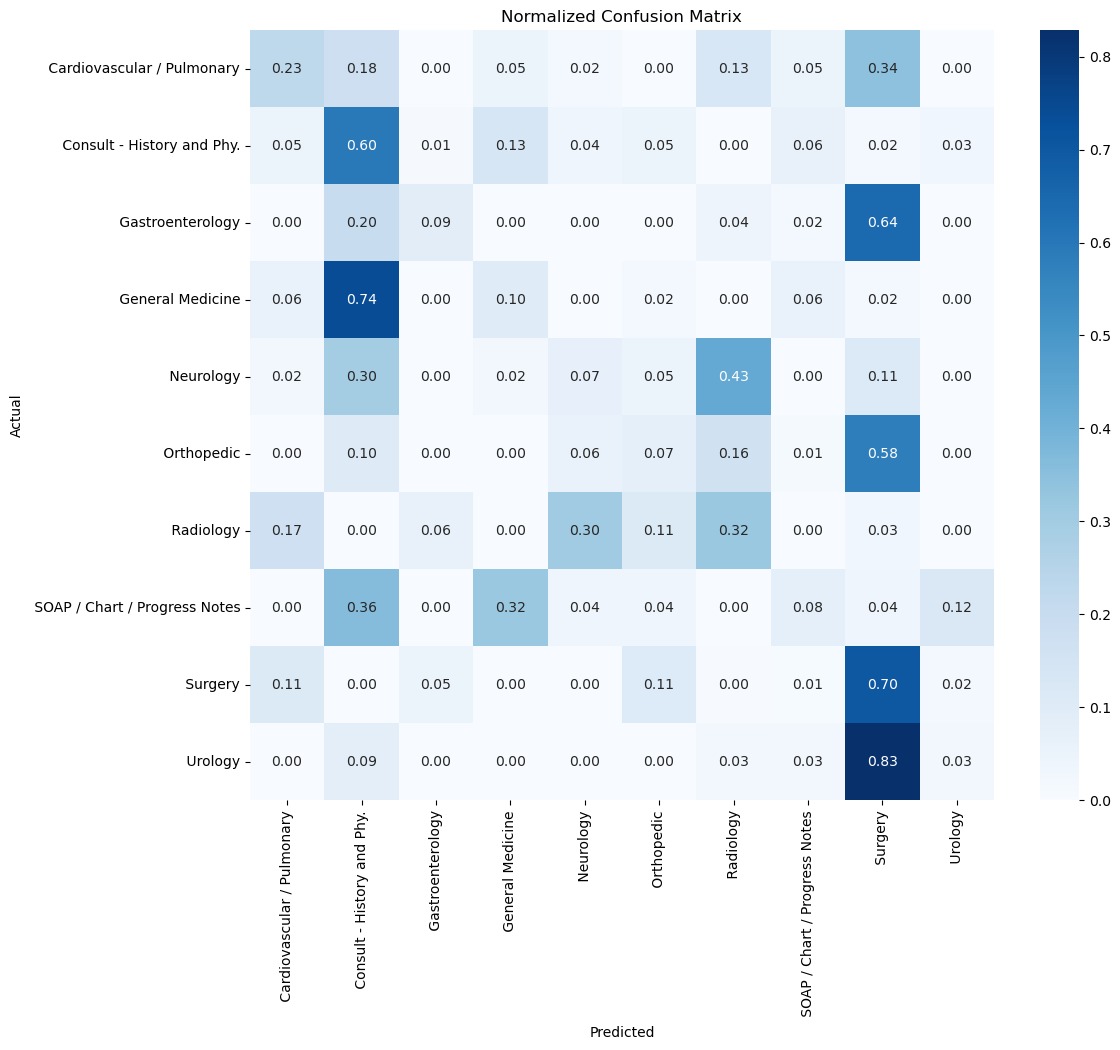

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Normalize the matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,10))

sns.heatmap(cm_normalized,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

## 5. Conclusion

This project developed a machine learning model to classify clinical notes into medical specialties using NLP techniques. The model achieved moderate performance, with stronger results for frequently occurring classes such as Surgery and Consultations.

The evaluation revealed that class imbalance significantly impacts performance, as the model tends to favor dominant categories while struggling with less frequent specialties. Additionally, similarities in medical language across specialties contribute to misclassification.

Future improvements could include handling class imbalance, applying advanced NLP techniques, and experimenting with more complex models to improve classification performance.

## 1. Improve model with SVM

In [50]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Create Linear SVM model
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
svm_y_pred = svm_model.predict(X_test)

# Evaluate accuracy
svm_accuracy = accuracy_score(y_test, svm_y_pred)
print("SVM Accuracy:", svm_accuracy)

# Detailed report
print(classification_report(y_test, svm_y_pred))

SVM Accuracy: 0.2751031636863824
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.11      0.11      0.11        61
    Consult - History and Phy.       0.36      0.45      0.40        97
              Gastroenterology       0.08      0.07      0.07        45
              General Medicine       0.10      0.08      0.09        50
                     Neurology       0.12      0.14      0.13        44
                    Orthopedic       0.09      0.09      0.09        67
                     Radiology       0.23      0.22      0.23        63
 SOAP / Chart / Progress Notes       0.08      0.08      0.08        25
                       Surgery       0.47      0.47      0.47       240
                       Urology       0.07      0.06      0.06        35

                      accuracy                           0.28       727
                     macro avg       0.17      0.18      0.17       727
                  weighted av

In [51]:
# Model comparison
print("Logistic Regression Accuracy:", accuracy)
print("SVM Accuracy:", svm_accuracy)

Logistic Regression Accuracy: 0.38514442916093533
SVM Accuracy: 0.2751031636863824


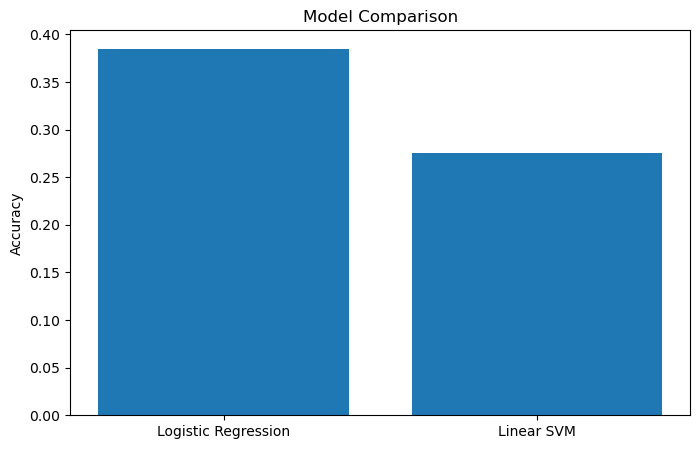

In [52]:
import matplotlib.pyplot as plt

model_names = ["Logistic Regression", "Linear SVM"]
model_scores = [accuracy, svm_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(model_names, model_scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

#### Normalized confusion matrix

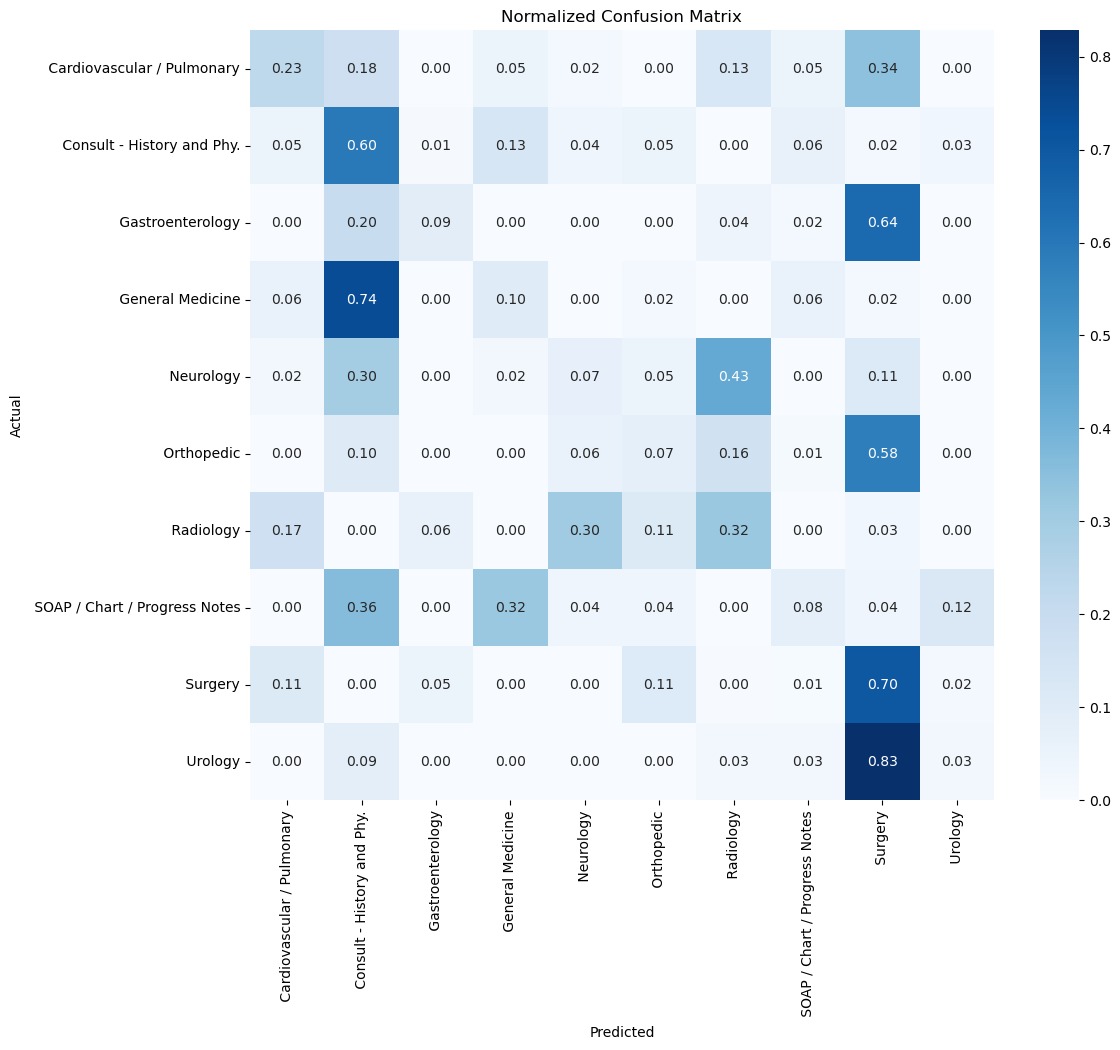

In [55]:
plt.figure(figsize=(12,10))

sns.heatmap(cm_normalized,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.savefig("../images/confusion_matrix.png", bbox_inches="tight")
plt.show()

### Model Comparison

Logistic Regression achieved higher accuracy (38.5%) compared to Linear SVM (27.5%). 

This indicates that, for this dataset, Logistic Regression provides better generalization performance. The lower performance of SVM may be due to class imbalance and the use of default hyperparameters.

This comparison highlights the importance of testing multiple models rather than assuming one model will always perform better.

In [54]:
# Saving the correct model

import joblib

# Save vectorizer
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

# Save best model (Logistic Regression)
joblib.dump(model, "../models/best_model.pkl")

['../models/best_model.pkl']